In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
#connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#excel sheet
dataset_path="/content/drive/MyDrive/AML/"

In [4]:
df=pd.read_excel(dataset_path +"metadata_with_data_dictionary.xlsx")

In [5]:
# Preview the first few rows to understand the dataset structure and values.
df.head()

,patient_id,sex_1f_2m,age,bag_label,instance_count,leucocytes_per_¬µl,pb_myeloblast,pb_promyelocyte,pb_myelocyte,pb_metamyelocyte,pb_neutrophil_band,pb_neutrophil_segmented,pb_eosinophil,pb_basophil,pb_monocyte,pb_lymph_typ,pb_lymph_atyp_react,pb_lymph_atyp_neopl,pb_other,pb_total
0,ABF,2,44.4,RUNX1_RUNX1T1,497,44.41,87,0,1,0,0,2,0,0,2,8,0,0.0,0,100
1,AEC,2,35.0,control,488,NaN,0,0,0,0,0,77,2,1,4,16,0,0.0,0,100
2,AIH,2,49.6,control,196,NaN,0,0,0,0,0,63,2,1,4,30,0,0.0,0,100
3,ALA,2,75.1,NPM1,494,13.80,85,0,1,0,1,4,0,0,3,6,0,0.0,0,100
4,ALE,1,43.8,PML_RARA,487,85.00,96,0,0,0,0,2,0,0,0,2,0,0.0,0,100


In [6]:
# Check column names, data types, and non-null counts.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               189 non-null    object 
 1   sex_1f_2m                189 non-null    int64  
 2   age                      189 non-null    float64
 3   bag_label                189 non-null    object 
 4   instance_count           189 non-null    int64  
 5   leucocytes_per_¬µl       117 non-null    float64
 6   pb_myeloblast            189 non-null    int64  
 7   pb_promyelocyte          189 non-null    int64  
 8   pb_myelocyte             189 non-null    int64  
 9   pb_metamyelocyte         189 non-null    int64  
 10  pb_neutrophil_band       189 non-null    int64  
 11  pb_neutrophil_segmented  189 non-null    int64  
 12  pb_eosinophil            189 non-null    int64  
 13  pb_basophil              189 non-null    int64  
 14  pb_monocyte              1

In [7]:
# Display the number of rows and columns in the dataset.
df.shape

(189, 20)

In [8]:
# Count missing values in each column.
df.isnull().sum()

,0
patient_id,0
sex_1f_2m,0
age,0
bag_label,0
instance_count,0
leucocytes_per_¬µl,72
pb_myeloblast,0
pb_promyelocyte,0
pb_myelocyte,0
pb_metamyelocyte,0


In [9]:
# Count the number of unique values in each column to identify low-variance columns.
unique_counts=df.nunique()
print(unique_counts)

patient_id                 189
sex_1f_2m                    2
age                        165
bag_label                    5
instance_count              72
leucocytes_per_¬µl         111
pb_myeloblast               67
pb_promyelocyte             14
pb_myelocyte                11
pb_metamyelocyte             5
pb_neutrophil_band           7
pb_neutrophil_segmented     57
pb_eosinophil                8
pb_basophil                  4
pb_monocyte                 35
pb_lymph_typ                49
pb_lymph_atyp_react          4
pb_lymph_atyp_neopl          1
pb_other                     6
pb_total                     3
dtype: int64


In [10]:
# Print all unique values column by column for a detailed data inspection.
for col in df.columns:
    print(f'{col}-{df[col].unique()}')

patient_id-['ABF' 'AEC' 'AIH' 'ALA' 'ALE' 'AQK' 'ATM' 'AVL' 'BHG' 'BHR' 'BHS' 'BIK'
 'BJK' 'BKR' 'BOE' 'BSN' 'BTB' 'BXR' 'CCO' 'CDA' 'CIQ' 'CMR' 'CVW' 'CWF'
 'CZI' 'DFT' 'DHA' 'DHE' 'DJJ' 'DNX' 'DPF' 'DPU' 'DQV' 'DSN' 'ECB' 'EEN'
 'EHM' 'ENH' 'FAQ' 'FDW' 'FED' 'FKU' 'FOH' 'FOL' 'FPW' 'FQY' 'FTW' 'FUT'
 'FYX' 'GEG' 'GJQ' 'GJZ' 'GOJ' 'GOP' 'GOR' 'GQB' 'GUE' 'GXQ' 'HEJ' 'HFM'
 'HMC' 'HNB' 'HQE' 'HQQ' 'HVE' 'HXQ' 'ICS' 'IEN' 'IIG' 'ILZ' 'IPY' 'IQS'
 'ISW' 'JFC' 'JGE' 'JRB' 'JTF' 'KDW' 'KOV' 'KRG' 'LAM' 'LBW' 'LCW' 'LGB'
 'LPA' 'LYD' 'MFH' 'MJF' 'MKF' 'MOR' 'MPP' 'MSC' 'NAR' 'NCD' 'NFI' 'NHB'
 'NOL' 'NPA' 'NRB' 'NRL' 'NUS' 'NVD' 'NXO' 'NXR' 'OCV' 'OEY' 'OHZ' 'ONF'
 'ORD' 'ORE' 'OTU' 'OUR' 'OVP' 'OYO' 'PAM' 'PBO' 'PCQ' 'PKC' 'POM' 'QBU'
 'QCF' 'QIZ' 'QQD' 'RDV' 'RFV' 'RGG' 'RHX' 'RJQ' 'RNQ' 'RPA' 'SBY' 'SDP'
 'SQF' 'SUN' 'SWN' 'SYY' 'TBZ' 'TOK' 'TPI' 'TVZ' 'TXH' 'UBG' 'UGU' 'UNX'
 'UOU' 'UVT' 'UWF' 'UXN' 'UZP' 'VAJ' 'VDQ' 'VMO' 'VPN' 'VXU' 'WOA' 'WSD'
 'WTE' 'WXO' 'XBB' 'XFF' 'XIE' 'XMA' 'XO

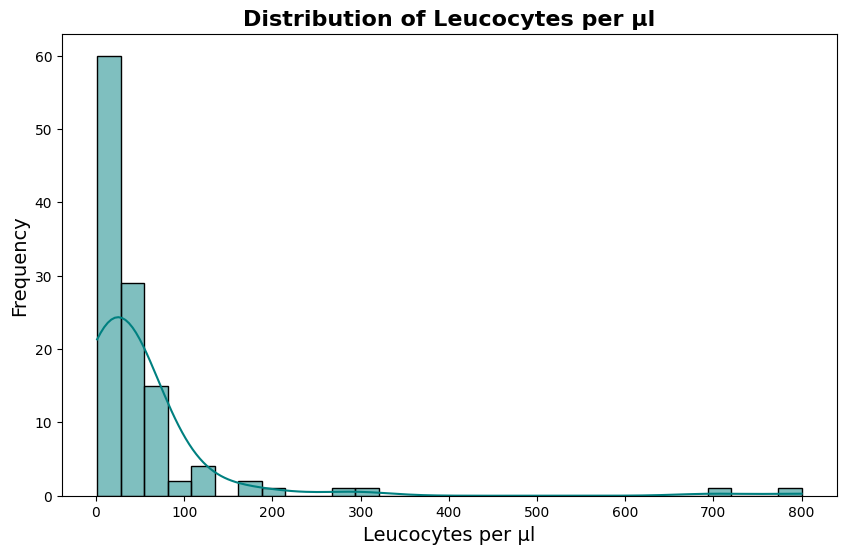

In [11]:
# Plot the distribution of leucocyte counts to understand spread, skewness, and possible outliers.
plt.figure(figsize=(10,6))
sns.histplot(df['leucocytes_per_¬µl'], bins=30, kde=True, color='teal')
plt.title('Distribution of Leucocytes per µl', fontsize=16, fontweight='bold')
plt.xlabel('Leucocytes per µl', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()


In [12]:
# Fill missing values in pb_lymph_atyp_neopl with 0 because this feature appears to represent absence in missing cases.
df['pb_lymph_atyp_neopl']=df['pb_lymph_atyp_neopl'].fillna(0)

In [13]:
# Check how many leucocyte values are missing within each AML/control group.
df.groupby('bag_label')['leucocytes_per_¬µl'].apply(lambda x:x.isna().sum())

,leucocytes_per_¬µl
bag_label,
CBFB_MYH11,6
NPM1,3
PML_RARA,1
RUNX1_RUNX1T1,2
control,60


In [14]:
# Count the number of samples in each subtype/class.
df['bag_label'].value_counts()

,count
bag_label,
control,60
CBFB_MYH11,37
NPM1,36
RUNX1_RUNX1T1,32
PML_RARA,24


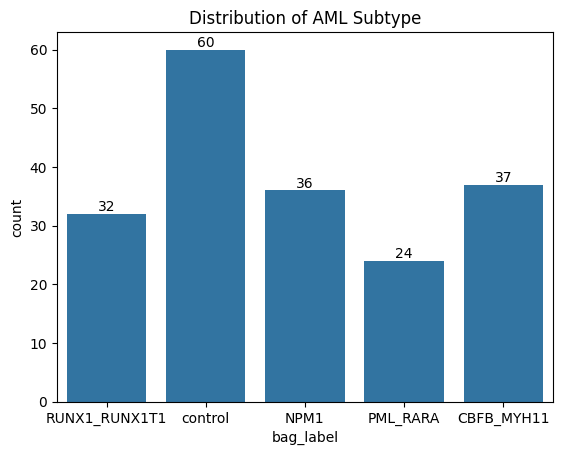

In [15]:
# Visualize class distribution and annotate exact counts on the bars.
ax=sns.countplot(x='bag_label',data=df)
plt.title('Distribution of AML Subtype')
for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )
plt.show()


In [ ]:
col = 'leucocytes_per_¬µl'

np.random.seed(42)

# 1. Fill missing control values with a normal-range random value
control_mask = (df['bag_label'] == 'control') & (df[col].isna())
df.loc[control_mask, col] = np.random.uniform(4, 11, size=control_mask.sum())

# 2. Fill remaining missing values in each subtype with that subtype median
df[col] = df.groupby('bag_label')[col].transform(
    lambda x: x.fillna(x.median())
)

In [17]:
# Recheck missing values after imputation.
df.isnull().sum()

,0
patient_id,0
sex_1f_2m,0
age,0
bag_label,0
instance_count,0
leucocytes_per_¬µl,0
pb_myeloblast,0
pb_promyelocyte,0
pb_myelocyte,0
pb_metamyelocyte,0


In [18]:
# Check whether the dataset contains duplicate rows.
df.duplicated().sum()

np.int64(0)

In [19]:
df = df.rename(columns={"leucocytes_per_¬µl": "leucocytes_per_ul"})

In [20]:
# Select important numeric clinical features and detect outliers using the IQR rule.
cols = [
'age',
'leucocytes_per_ul',
'pb_myeloblast',
'pb_promyelocyte',
'pb_myelocyte',
'pb_metamyelocyte',
'pb_neutrophil_band',
'pb_neutrophil_segmented',
'pb_eosinophil',
'pb_basophil',
'pb_monocyte',
'pb_lymph_typ',
'pb_lymph_atyp_react',
'pb_lymph_atyp_neopl',
'pb_other'
]

def detect_outliers(column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(column, "outliers:", len(outliers))

for col in cols:
    detect_outliers(col)


age outliers: 0
leucocytes_per_ul outliers: 12
pb_myeloblast outliers: 0
pb_promyelocyte outliers: 37
pb_myelocyte outliers: 22
pb_metamyelocyte outliers: 16
pb_neutrophil_band outliers: 37
pb_neutrophil_segmented outliers: 0
pb_eosinophil outliers: 2
pb_basophil outliers: 44
pb_monocyte outliers: 14
pb_lymph_typ outliers: 2
pb_lymph_atyp_react outliers: 8
pb_lymph_atyp_neopl outliers: 0
pb_other outliers: 10


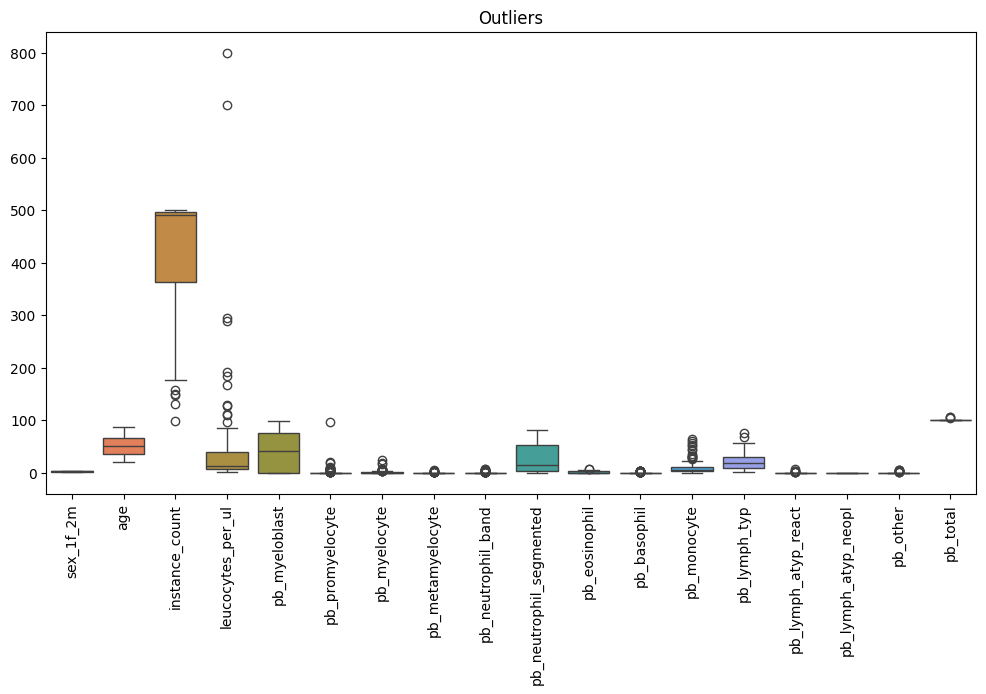

In [21]:
# Boxplot of all numeric features to visually inspect outliers and scale differences.
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.title("Outliers")
plt.show()

In [22]:
# Sum the peripheral blood percentage columns and compare with pb_total for consistency checking.
pb_cols = [
'pb_myeloblast','pb_promyelocyte','pb_myelocyte','pb_metamyelocyte',
'pb_neutrophil_band','pb_neutrophil_segmented','pb_eosinophil',
'pb_basophil','pb_monocyte','pb_lymph_typ','pb_lymph_atyp_react',
'pb_lymph_atyp_neopl','pb_other'
]

df['pb_sum'] = df[pb_cols].sum(axis=1)

df[['pb_sum','pb_total']].head()

,pb_sum,pb_total
0,100.0,100
1,100.0,100
2,100.0,100
3,100.0,100
4,100.0,100


In [23]:
# Drop columns not needed for modeling: patient_id, pb_total, and instance_count.
df=df.drop(columns=['pb_total','instance_count','pb_sum'])

In [24]:
# Drop pb_lymph_atyp_neopl because it has almost no variation / limited useful information.
df=df.drop(columns=['pb_lymph_atyp_neopl'])

In [25]:
label_map = {
    "control": 0,
    "NPM1": 1,
    "PML_RARA": 2,
    "RUNX1_RUNX1T1": 3,
    "CBFB_MYH11": 4
}

df["target_multi"] = df["bag_label"].map(label_map)

In [26]:
print(df["target_multi"].value_counts())

target_multi
0    60
4    37
1    36
3    32
2    24
Name: count, dtype: int64


In [27]:
df_pca=df.copy()

In [28]:
df = df.drop(columns=["bag_label"])

In [29]:
df.to_csv("/content/drive/MyDrive/AML/cleaned_clinical_data.csv", index=False)

print("Saved successfully")
print(df.shape)
df.head(189)

Saved successfully
(189, 17)


,patient_id,sex_1f_2m,age,leucocytes_per_ul,pb_myeloblast,pb_promyelocyte,pb_myelocyte,pb_metamyelocyte,pb_neutrophil_band,pb_neutrophil_segmented,pb_eosinophil,pb_basophil,pb_monocyte,pb_lymph_typ,pb_lymph_atyp_react,pb_other,target_multi
0,ABF,2,44.4,44.410000,87,0,1,0,0,2,0,0,2,8,0,0,3
1,AEC,2,35.0,6.621781,0,0,0,0,0,77,2,1,4,16,0,0,0
2,AIH,2,49.6,10.655000,0,0,0,0,0,63,2,1,4,30,0,0,0
3,ALA,2,75.1,13.800000,85,0,1,0,1,4,0,0,3,6,0,0,1
4,ALE,1,43.8,85.000000,96,0,0,0,0,2,0,0,0,2,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,ZNL,2,34.8,6.277312,0,0,0,0,1,45,1,0,4,49,0,0,0
185,ZRJ,1,54.0,3.700000,34,0,0,0,0,15,1,0,25,25,0,0,4
186,ZVS,2,74.3,30.000000,66,0,0,0,0,3,3,2,13,13,0,0,4
187,ZVX,1,48.9,12.600000,89,0,0,0,0,9,0,0,0,2,0,0,3


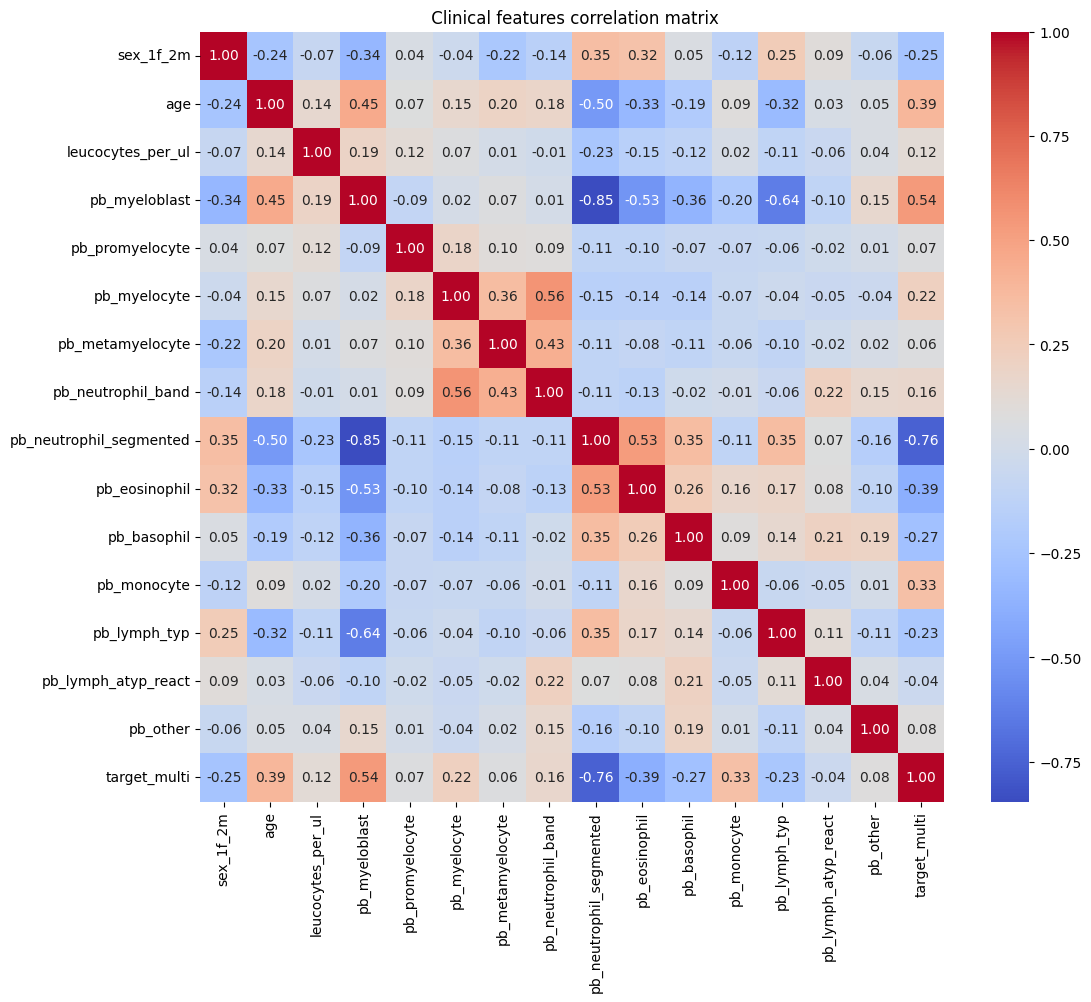

In [30]:
# Compute the correlation matrix for numeric features and visualize it as a heatmap.
numeric_df=df.select_dtypes(include=['int64','float64'])
corr_matrix=numeric_df.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(' Clinical features correlation matrix')
plt.show()


In [31]:
# Extract and print the strongest feature-to-feature correlations.
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
sorted_pairs = upper.unstack().dropna().abs().sort_values(ascending=False)

print("Top correlated pairs:")
print(sorted_pairs.head(10))


Top correlated pairs:
pb_neutrophil_segmented  pb_myeloblast              0.845761
target_multi             pb_neutrophil_segmented    0.755945
pb_lymph_typ             pb_myeloblast              0.635057
pb_neutrophil_band       pb_myelocyte               0.563899
target_multi             pb_myeloblast              0.535856
pb_eosinophil            pb_neutrophil_segmented    0.526806
                         pb_myeloblast              0.525899
pb_neutrophil_segmented  age                        0.501599
pb_myeloblast            age                        0.454989
pb_neutrophil_band       pb_metamyelocyte           0.430799
dtype: float64


In [32]:
df_pca=df_pca.drop(columns=['patient_id','bag_label'])

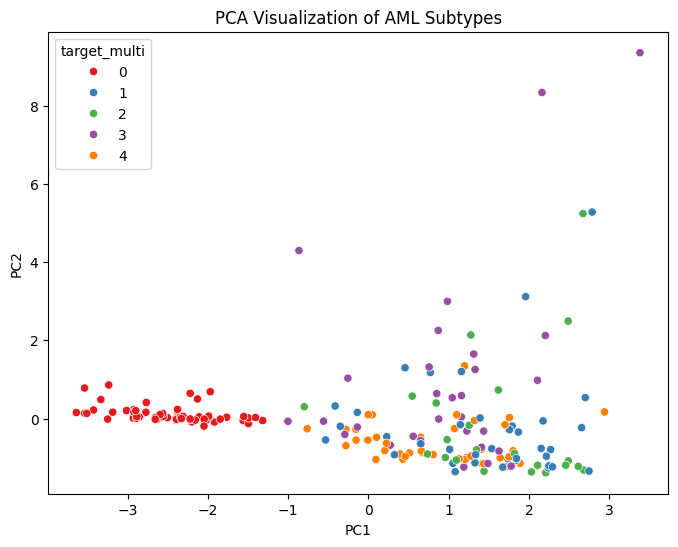

In [33]:
# Reduce features to 2 principal components for visualization of subtype separation.
X = df_pca.drop(columns=["target_multi"])
y = df_pca["target_multi"]

X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(8,6))


sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette="Set1"
)

plt.title("PCA Visualization of AML Subtypes")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()
